In [ ]:
import warnings

#  Data Preprocessing

Data Preprocessing: clean / organise the input data into the format required by the models. <br>

#### setting the constants

In [ ]:
use_polynomials = False
# False means we use the Lagged Values approach
# True would mean Polynomials Transform

HORIZON = 24
# We forecast 24 hours ahead (day-ahead, h = 24).
# This is the standard operational horizon for electricity market clearing in Panama.

LAG_1 = 24
# 24-hour lag: same hour yesterday, relative to the CURRENT/input row. Used in hydro STATE
# features (hidro_fraction_L24, hidro_delta_L24, hidro_anomaly_L24) — those describe "what was
# the system doing as of now", so input-relative is the correct framing there and is unchanged.

LAG_2 = 312
LAG_3 = 144
# TARGET-relative lags: residual_L{144,312} give the residual demand at the SAME clock-hour,
# exactly 1/2 weeks before the hour being PREDICTED (target_time = input + 24h), not before the
# input row itself. Training-only Pearson r confirms this is the stronger framing:
# r(144) = 0.780, r(312) = 0.764.

MAX_LAG = LAG_2
# Burn-in: LAG_2=312 is still the largest backward-looking shift used anywhere (> LAG_3=144,
# residual_L48's 48, and LAG_1*2=48), so MAX_LAG=LAG_2 remains a correct, sufficient upper bound.
# The first MAX_LAG rows are dropped after feature construction to avoid NaN values.

LAG_2 and LAG_3 were chosen over LAG_1 (r ≈ 0 with the target) by Pearson correlation analysis.
LAG_1 (24 h) was dropped because it is nearly collinear with the current value of `demanda_residual`,
adding no information. The 48-hour lag (training-only r = 0.575) is included as `residual_L48` in
the feature list below — kept input-relative since target_time is always input+24h anyway, so a
"48h before input" and "72h before target" framing are just two names for the same feature.

#### data download

In [ ]:
import requests, json as _json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows",    None)
pd.set_option("display.max_columns", None)

In [4]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent='etesa_tfm')
# Create a geolocator object using the OpenStreetMap Nominatim service.
# user_agent is a required label so the service knows who is calling it.

place = input('Enter location (e.g. Penonomé, Coclé, Panama): ')
# Ask the user to type the name of the location for the API query.

information = geolocator.geocode(place)
# Convert the place name into geographic coordinates (geocoding).

lat = information[1][0]
lon = information[1][1]
# Extract latitude and longitude from the geocoder result tuple.

print(lat, lon)
# Display the coordinates to verify they correspond to the intended location.

Enter location (e.g. Penonomé, Coclé, Panama): Cocle, Penonome
8.5204989 -80.359579


In [5]:
token    = 'c4672deddb9f6acfa94e9cdbb34f6414fd51f255'
# Personal access token for the Renewables.ninja API — replace with your own if expired.

api_base   = 'https://www.renewables.ninja/api/'
url_solar  = api_base + 'data/pv'
url_wind   = api_base + 'data/wind'
# Two endpoint URLs: one for photovoltaic (solar) and one for wind power output.

args_solar = {
    'lat': lat, 'lon': lon,
    'date_from': '2025-01-01', 'date_to': '2025-12-31',
    # Full calendar year 2025 — matches the ETESA real-generation data period.
    'dataset':  'merra2',
    # MERRA-2 is NASA's reanalysis product: global, hourly, 0.5° × 0.625° grid.
    'capacity':     859000,   # installed solar capacity in kW (859 MW in Panama 2025)
    'system_loss':  0.1,      # 10 % system losses (wiring, inverter, soiling)
    'tracking':     1,        # single-axis tracking (tilts panel to follow the sun)
    'tilt':         5,        # 5° fixed tilt (small tilt helps rain cleaning)
    'azim':         180,      # south-facing azimuth (optimal for Northern Hemisphere)
    'format':       'json',
    'local_time':   'true',   # return timestamps in Panama local time (UTC-5)
    'raw':          'true',   # include raw meteorological variables (irradiance, temp)
}

args_wind = {
    'lat': lat, 'lon': lon,
    'date_from': '2025-01-01', 'date_to': '2025-12-31',
    'capacity':  336000,                      # installed wind capacity in kW (336 MW)
    'height':    150,                          # hub height in metres
    'turbine':   'Vestas V80 2000',            # turbine model for power curve lookup
    'format':    'json',
    'local_time': 'true',
    'raw':        'true',
}
# The raw flag returns irradiance_direct, irradiance_diffuse, temperature, wind_speed —
# which become our meteorological features and, shifted by -24, the NWP horizon covariates.

In [ ]:
s = requests.session()
s.headers = {'Authorization': 'Token ' + token}
# Create an HTTP session and attach the API token to every request header.

# ── Solar ────────────────────────────────────────────────────────────────────────
r = s.get(url_solar, params=args_solar)
print('Solar status:', r.status_code)
# Status 200 means the request succeeded. Any other code indicates an error.

with open('renewables_ninja_solar_raw.json', 'w') as _f:
    _f.write(r.text)
# Save the raw, unprocessed API response so a run's exact inputs can be reproduced/verified
# later, independent of anything this script does to them downstream.

parsed_solar = _json.loads(r.text)
# Parse the raw JSON text into a Python dictionary.

data = pd.read_json(_json.dumps(parsed_solar['data']), orient='index')
# The 'data' key holds the time-indexed results. orient='index' tells pandas that
# the outer dictionary keys are the row indices (timestamps).

data['electricity'] = data['electricity'] / 1000
# Convert from kW (the API default) to MW (our working unit for ETESA data).

data['local_time'] = pd.to_datetime(data['local_time']).dt.tz_localize(None)
# Convert the timestamp string to a pandas datetime and strip timezone info
# so it aligns cleanly with the ETESA real-generation data (which is tz-naive).

data = data.set_index('local_time')
# Use the timestamp as the row index for time-series alignment.

# ── Wind ─────────────────────────────────────────────────────────────────────────
r_wind = s.get(url_wind, params=args_wind)
with open('renewables_ninja_wind_raw.json', 'w') as _f:
    _f.write(r_wind.text)
# Save the raw wind response too, same reproducibility rationale as the solar one above.
parsed_wind = _json.loads(r_wind.text)
wind_data = pd.read_json(_json.dumps(parsed_wind['data']), orient='index')
wind_data['local_time'] = pd.to_datetime(wind_data['local_time']).dt.tz_localize(None)
wind_data = wind_data.set_index('local_time')
wind_data['electricity'] = wind_data['electricity'] / 1000
# Same pipeline as solar — convert kW→MW and set the timestamp index.

In [ ]:
# ── Combine API outputs ──────────────────────────────────────────────────────────
df_combined = pd.concat([
    data[['irradiance_direct','irradiance_diffuse','temperature','electricity']].rename(
        columns={'electricity': 'solar_mw'}),
    wind_data[['wind_speed','electricity']].rename(
        columns={'electricity': 'wind_mw'})
], axis=1).dropna()
# Concatenate the solar columns and the wind columns side by side (axis=1).
# dropna() removes any hour where at least one API value is missing.

df_combined.index = df_combined.index + pd.Timedelta(hours=1)
# Renewables.ninja labels by interval START (hour-beginning); ETESA files label by interval
# END (hour-ending, see the H_k -> k:00 fix below). Shifted to match, confirmed empirically
# (solar ramp/peak/decay land exactly 1h earlier under the old, unshifted join).

df_combined.to_csv('renewables_ninja_2025.csv')
# Export a copy of the downloaded API data (all six meteorological columns) so the
# exact weather inputs behind a run are preserved on disk and results can be traced
# back to them.

# ── Load ETESA real-generation data from CSV ─────────────────────────────────
real = pd.read_csv('solar_eolica_hidro_horario_2025.csv', index_col=0, parse_dates=True)
real.index = pd.to_datetime(real.index)
# Read the CSV file. index_col=0 restores the datetime index, parse_dates ensures
# the index is parsed as datetime64.
# Columns: solar_mw_real, eolica_mw_real, hidro_mw_real — real ETESA metered values.

cols_to_drop = [c for c in real.columns if c in df_combined.columns]
df_combined  = df_combined.drop(columns=cols_to_drop).join(real, how='left')
# Drop any duplicate columns before joining, then left-join to keep every ninja row
# and attach the real ETESA generation columns.

# ── Load ETESA real demand from CSV ────────────────────────────────────────────
demanda_raw = pd.read_csv('DEM2025.csv')
# Wide CSV: first column = dates (Unnamed: 0), H1..H24 = hourly demand.

demanda_raw = demanda_raw.rename(columns={demanda_raw.columns[0]: 'fecha'})
# Rename the first column to 'fecha' for clarity.

demanda_long = demanda_raw.melt(id_vars=['fecha'], var_name='hora_str', value_name='demanda_mw')
# Convert the wide format (one column per hour) to long format (one row per hour),
# producing columns: fecha, hora_str (e.g. 'H1'), demanda_mw.

demanda_long  = demanda_long.dropna(subset=['fecha'])
demanda_long['fecha_dt']  = pd.to_datetime(demanda_long['fecha'], errors='coerce')

_bad_dates = sorted(demanda_long.loc[demanda_long['fecha_dt'].isna(), 'fecha'].unique())
if _bad_dates:
    print(f'WARNING: dropping {len(_bad_dates)} unparseable date(s) from DEM2025.csv: {_bad_dates}')

demanda_long  = demanda_long.dropna(subset=['fecha_dt'])
# Parse dates; drop any rows where the date cannot be converted.

demanda_long['hora_num'] = (
    demanda_long['hora_str'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
)
# HOUR-ENDING convention: the generation file runs 2025-01-01 01:00 -> 2026-01-01 00:00 =
# exactly 8760 rows (365x24) - only possible if hours are labeled by when they END (00:00-01:00
# stamped 01:00). So H_k maps to k:00. Renewables.ninja weather timestamps use hour-BEGINNING
# instead - shifted to match this convention where df_combined is built, above.

demanda_long['timestamp'] = (
    demanda_long['fecha_dt'] + pd.to_timedelta(demanda_long['hora_num'], unit='h')
)
# Build a proper datetime timestamp by adding the hour-ending offset to the date.

demanda_long = demanda_long.set_index('timestamp')[['demanda_mw']].sort_index()
demanda_long['demanda_mw'] = pd.to_numeric(demanda_long['demanda_mw'], errors='coerce')
# Set the timestamp as the index, keep only the demand column, sort chronologically.

if 'demanda_mw' in df_combined.columns:
    df_combined = df_combined.drop(columns=['demanda_mw'])
# Guard against duplicate column names before the join.

df_combined = df_combined.join(demanda_long, how='left')
# Join the demand series onto the meteorological data using the datetime index.

df_combined = df_combined[df_combined.index >= '2025-01-01 01:00:00']
# Drop the incomplete first hour (00:00 row often has missing demand data from ETESA).

df = df_combined
print('Columns:', df.columns.tolist())

# Index integrity: every lag/shift feature below assumes "N rows back =
# N hours back". That only holds if the hourly index is complete (no gaps) and unique
# (no duplicate timestamps). Assert it explicitly rather than trusting row position —
# a single missing or duplicated hour would silently make a 24-row shift != 24 hours.
_idx = pd.DatetimeIndex(df.index)
_dupes = _idx[_idx.duplicated()]
assert _dupes.empty, f'Duplicate timestamps in the hourly index: {list(_dupes[:5])}'
_full = pd.date_range(_idx.min(), _idx.max(), freq='h')
_missing = _full.difference(_idx)
assert _missing.empty, (
    f'{len(_missing)} missing hour(s) in the index (e.g. {list(_missing[:5])}); '
    f'row-count-based shifts would be wrong. Reindex to a complete hourly range first.'
)
print(f'Index OK: {len(_idx):,} unique, gap-free hourly rows '
      f'({_idx.min()} -> {_idx.max()}).')

#### calibration

The Renewables.ninja API provides MERRA-2 reanalysis data scaled to the installed capacity.
However, the real irradiance measured at the Panama solar plants differs from the MERRA-2 signal.
We calibrate it using a per-hour real/ninja ratio fit from **training rows only**, inside each
rolling window (`rebuild_calibration_features`), applied using only ninja inputs — never real
solar from the window being forecast, so the calibration cannot leak target information.

In [ ]:
# Keep raw ninja irradiance + ninja solar here; the real/ninja calibration factor is re-fit
# from TRAINING ROWS ONLY per rolling window in rebuild_calibration_features (called by
# get_targets_features), applied using only ninja inputs.
df['irr_direct_ninja']  = df['irradiance_direct']
df['irr_diffuse_ninja'] = df['irradiance_diffuse']
df['solar_ninja']       = df['solar_mw']
# irradiance_direct / irradiance_diffuse stay as RAW ninja here (placeholder for the EDA plots
# only); they are OVERWRITTEN per rolling window during modelling, never reaching the models raw.

df['solar_mw']  = df['solar_mw_real']
df['eolica_mw'] = df['eolica_mw_real']
df['hidro_mw']  = df['hidro_mw_real']
# Replace the Ninja electricity outputs with the real ETESA metered values.
# This is critical: we must forecast against real observed generation, not modelled output.

cols_order = [
    'irradiance_direct','irradiance_diffuse','temperature',
    'solar_mw','wind_speed','eolica_mw','hidro_mw','demanda_mw',
    # Raw ninja helpers kept so rebuild_calibration_features can re-fit per window (not fed to
    # the models - see the explicit features_h24 definition, which draws from cols_order only).
    'irr_direct_ninja','irr_diffuse_ninja','solar_ninja',
]
df = df[cols_order]
# Retain only the base columns we need. All other API columns (e.g. wind_mw from Ninja)
# are replaced by the calibrated real-data versions.

print(f'Base: {df.shape[1]} cols, {df.shape[0]} records.')
print(f'hidro_mw — mean={df.hidro_mw.mean():.0f} MW  min={df.hidro_mw.min():.0f}  max={df.hidro_mw.max():.0f}')
# Print a quick sanity check: typical hydro range for Panama is 600–1400 MW.

#### check for missing values

In [9]:
df.isnull().sum()
# Count the number of NaN values in each column.
# A non-zero count means we have missing hours that must be handled before modelling.

,0
irradiance_direct,0
irradiance_diffuse,0
temperature,0
solar_mw,0
wind_speed,0
eolica_mw,0
hidro_mw,0
demanda_mw,0


#### correct datatypes

In [ ]:
df.reset_index(inplace=True)
# Move the datetime index back into a regular column called 'local_time'.
# This allows us to use .dt accessor methods to extract hour, month, day-of-week.

#### feature engineering — calendar and cyclic features

The ETESA load follows strong intra-day and intra-week patterns. We encode these using:
- **Integer features** (`month`, `hour`, `is_weekday`) for tree models.
- **Cyclic features** (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`, `dow_sin`, `dow_cos`)
  so that the DNN recognises that hour 23 is adjacent to hour 0, and December is adjacent to January.
- **Holiday indicator** (`is_holiday`): binary flag for the 14 official Panamanian public holidays in 2025.
- **Interaction feature** (`hour_weekday = hour × is_weekday`): captures the midday peak that only
  occurs on working days — small but consistent gain for tree models.

In [ ]:
df['month'] = df['local_time'].dt.month
# Extract the calendar month (1–12) as an integer feature.

df['hour']  = df['local_time'].dt.hour
# Extract the hour of day (0–23) as an integer feature.

df['is_weekday'] = (df['local_time'].dt.dayofweek < 5).astype(int)
# 1 if Monday–Friday, 0 if Saturday–Sunday.
# dayofweek returns 0=Monday … 6=Sunday.

df['hour_weekday'] = df['hour'] * df['is_weekday']
# Interaction feature: equals the hour value on weekdays, zero on weekends.
# Captures the different diurnal shapes between working and non-working days.

# National holidays
_panama_holidays_2025 = [
    '2025-01-01', '2025-01-09', '2025-03-04', '2025-03-05', '2025-04-18',
    '2025-05-01', '2025-08-15', '2025-11-03', '2025-11-04', '2025-11-05',
    '2025-11-10', '2025-11-28', '2025-12-08', '2025-12-25',
]
_holiday_set = {pd.Timestamp(d).date() for d in _panama_holidays_2025}
# Build a set of date objects for O(1) lookup.

df['is_holiday'] = df['local_time'].dt.date.map(lambda d: int(d in _holiday_set))
# Map each row's date to 1 (holiday) or 0 (not a holiday).
# Note: is_holiday is a SPARSE binary feature (only 14 days per year = ~1 of the data).
# It is suitable for flat feature spaces (XGBoost handles sparse splits well),


# ── Day-of-week cyclic encoding ───────────────────────────────────────────────────
df['dow_sin'] = np.sin(2 * np.pi * df['local_time'].dt.dayofweek / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['local_time'].dt.dayofweek / 7)
# Cyclic encoding ensures that Sunday (6) and Monday (0) are numerically close.
# sin and cos together uniquely encode each day (neither alone does so).

datetime_index = df['local_time'].copy()
df = df.drop(columns=['local_time'])
# Save the datetime column separately so we can use it for plot axes later,
# then remove it from the feature DataFrame.

print(f'Holidays 2025: {len(_panama_holidays_2025)} days → {df.is_holiday.sum()} hours marked')

#### target variable and feature construction

The **residual demand** is defined as:

> `demanda_residual = demanda_mw − solar_mw − eolica_mw`

This is the portion of demand that must be met by hydroelectric, thermal, and imports
not by variable renewables. Forecasting residual demand is the core operational problem
under high renewable penetration, because residual demand drives hydroelectric dispatch
scheduling and thermal unit commitment decisions.

The **lag features** are the pre-computed shifted values of `demanda_residual`.
The NWP horizon features are the meteorological values shifted 24 hours forward (future NWP at the target time).
The hydro dispatch features capture the operational state of the hydroelectric fleet.

In [ ]:
# Target: residual demand
df['demanda_residual'] = df['demanda_mw'] - df['solar_mw'] - df['eolica_mw']
# Residual demand = total demand minus variable renewables (solar + wind).
# This is what hydro + thermal must supply. Our forecasting target.

# Cyclic encoding
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
# Encode the hour of day cyclically. Period = 24 hours.

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
# Encode the month of year cyclically. Period = 12 months.

# ── Lagged target features (Lagged Approach)
# Training-only Pearson correlations with target: r(L144)=0.780 > r(L312)=0.764 > r(L48)=0.575
# r(L24) ≈ 0  →  dropped (nearly collinear with the current-hour 'demanda_residual').

df['residual_L312'] = df['demanda_residual'].shift(LAG_2)
# 312-hour lag: residual demand at the SAME clock-hour, exactly 2 weeks before the hour being
# predicted — captures the biweekly hydroelectric dispatch cycle.

df['residual_L144'] = df['demanda_residual'].shift(LAG_3)
# 144-hour lag: residual demand at the SAME clock-hour, exactly 1 week before the hour being
# predicted. Strongest single lag predictor (r = 0.780).

df['residual_L48']  = df['demanda_residual'].shift(48)
# 48-hour lag (2 days): captures the mid-week demand build-up pattern.

# NWP Horizon features at t+24 — the h=24 meteorology at the prediction target time.
#
# ── LIMITATION: PERFECT-FORESIGHT WEATHER ─────────────────────────────────────
# These four features are built with shift(-HORIZON), i.e. the TRUE future value of
# the MERRA-2 reanalysis, not an actual forecast. The full year was pulled from the
# Renewables.ninja API in one request, so at "prediction time" the model is handed
# the exact weather that will occur 24 h later. Results therefore assume a PERFECT 24 h
# weather forecast and are an optimistic upper bound. A real day-ahead deployment would
# feed operational NWP (e.g. GFS/ECMWF) instead, whose forecast error would raise the
# reported MAPE/WAPE. Treat the h24 weather block as a perfect-foresight proxy.
df['irradiance_direct_h24']  = df['irradiance_direct'].shift(-HORIZON)
df['irradiance_diffuse_h24'] = df['irradiance_diffuse'].shift(-HORIZON)
df['temperature_h24']        = df['temperature'].shift(-HORIZON)
df['wind_speed_h24']         = df['wind_speed'].shift(-HORIZON)
# Raw-ninja h+24 shifts, built here (pre-trim, so the shift has successors) and kept so the
# per-window calibration (rebuild_calibration_features) can rebuild the two irradiance_*_h24
# columns from ninja x a training-only factor, with no NaN at the tail. Not fed to the models.
df['irr_direct_ninja_h24']   = df['irr_direct_ninja'].shift(-HORIZON)
df['irr_diffuse_ninja_h24']  = df['irr_diffuse_ninja'].shift(-HORIZON)

# Hydro dispatch features
# hidro_mw stays as a raw feature (see cols_order below). hidro_mw + termica_mw = demanda_residual
# by definition, but termica_mw isn't in this dataset, so hidro_mw alone doesn't fully determine
# the target — not perfect collinearity. Its low XGBoost importance (gain ≈ 0.005) is redundancy
# with the already-present demanda_residual feature, not danger. The four derived features below
# add hydro-specific information (share, trend, seasonal deviation) the raw level doesn't carry.

df['hidro_fraction_L24'] = (
    df['hidro_mw'].shift(LAG_1) /
    df['demanda_residual'].shift(LAG_1).replace(0, np.nan)
).clip(0, 1.5).fillna(0.5)
# Yesterday's hydro share of residual demand (0–1.5, clipped for outliers).
# Captures whether the system was in a hydro-heavy or hydro-light operational state.

df['hidro_delta_L24'] = (
    df['hidro_mw'].shift(LAG_1) - df['hidro_mw'].shift(LAG_1 * 2)
).fillna(0)
# Day-over-day trend in hydro dispatch. Positive = reservoir building, negative = drawing down.

# Seasonal-diurnal hydro baseline = (month, hour) mean of hidro_mw.
# NOTE: the full-year profile below is used ONLY for EDA / correlation plots and to keep
# the column layout fixed. During modelling these two columns are REBUILT per rolling
# window from training-only data by rebuild_hidro_profile_features() (see get_targets_features),
# so no window is fed a seasonal average that includes months past its own cutoff.
_hidro_profile = df.groupby(['month', 'hour'])['hidro_mw'].transform('mean')

# hidro_typical_h24 = expected hydro at the forecast horizon (h+24).
df['hidro_typical_h24'] = _hidro_profile.shift(-HORIZON)

# hidro_anomaly_L24 = yesterday's deviation of actual hydro from its seasonal baseline
# (positive = surplus reservoir conditions; negative = drought / low-water stress).
df['hidro_anomaly_L24'] = (df['hidro_mw'] - _hidro_profile).shift(LAG_1)

# Target at h+24
df['demanda_residual_h24'] = df['demanda_residual'].shift(-HORIZON)
# The value we want to predict: residual demand 24 hours ahead.
# shift(-24) aligns each row's features with the target 24 hours later.

#Final feature order: 30 flat features + 1 target
cols_order = [
    # Current meteorology (7)
    'irradiance_direct', 'irradiance_diffuse', 'temperature',
    'solar_mw', 'wind_speed', 'eolica_mw', 'hidro_mw',
    # NWP horizon covariates at t+24 (4) ← most impactful group
    'irradiance_direct_h24', 'irradiance_diffuse_h24',
    'temperature_h24', 'wind_speed_h24',
    # Calendar features (11)
    'month', 'hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekday', 'hour_weekday', 'is_holiday', 'dow_sin', 'dow_cos',
    # Lagged target — Lagged Approach (4)
    'demanda_residual',
    'residual_L48', 'residual_L312', 'residual_L144',
    # Hydro dispatch state (4)
    'hidro_fraction_L24', 'hidro_delta_L24', 'hidro_typical_h24', 'hidro_anomaly_L24',
    # Target (1)
    'demanda_residual_h24',
]
# Raw ninja helper columns retained alongside cols_order so rebuild_calibration_features can
# re-fit the leakage-safe calibration per rolling window. Not model features (features_h24 is
# defined from cols_order only, below).
NINJA_HELPERS  = ['irr_direct_ninja', 'irr_diffuse_ninja', 'solar_ninja',
                  'irr_direct_ninja_h24', 'irr_diffuse_ninja_h24']
df             = df[cols_order + NINJA_HELPERS]
# Trim: drop first MAX_LAG rows (NaN from lag features) and last HORIZON rows (NaN from future shift).
df             = df.iloc[MAX_LAG:-HORIZON].reset_index(drop=True)
datetime_index = datetime_index.iloc[MAX_LAG:-HORIZON].reset_index(drop=True)
# Also trim datetime_index to match the trimmed df row-for-row.

# origin_time / target_time: origin_time[i] = "now", when row i's
# features are known. The model's prediction at row i is for target_time[i] = origin_time[i]+24h.
# So a 24-row block starting at T_day is ONE COMPLETED DAY of known inputs (origin_time), used
# to forecast the FOLLOWING day (target_time). Plots/forecasts below index by target_time, so
# the x-axis reads the day being predicted, not the day the forecast was issued from.
origin_time = datetime_index
target_time = datetime_index + pd.Timedelta(hours=HORIZON)

print(f'Records:  {len(df):,} hourly ({len(df)/24:.0f} days)')
print(f'Datetime: {datetime_index.iloc[0]} → {datetime_index.iloc[-1]}')
print(f'Features: {len(df.columns)-1} flat + 1 target = {len(df.columns)} columns')
df.describe().round(2)

#Exploratory Data Analysis

EDA: inspect the data through plots, autocorrelation, and correlation analysis.
This section plot the data → check stationarity → correlation matrix.

#### plot the data

In [ ]:
df[cols_order].plot(subplots=True, figsize=(14, 42), layout=(16, 2))
# Plot each of the 31 columns in its own sub-panel.
# layout=(16, 2) gives 32 slots — enough for 31 columns. layout=(9, 2) would fail (only 18 slots).
plt.tight_layout()
plt.show()

#### autocorrelation analysis and target scatter

The ACF reveals the dominant periodic structure: peaks at lags 24 (daily), 168 (weekly),
and 336 (biweekly). These directly motivate the choice of lag features.
The scatter plot confirms that the current residual demand is a useful but imperfect predictor
of the 24-hour-ahead target (r ≈ 0.69 in the actual run), justifying the addition of lag and
NWP features to explain the remaining ~50 % of variance.

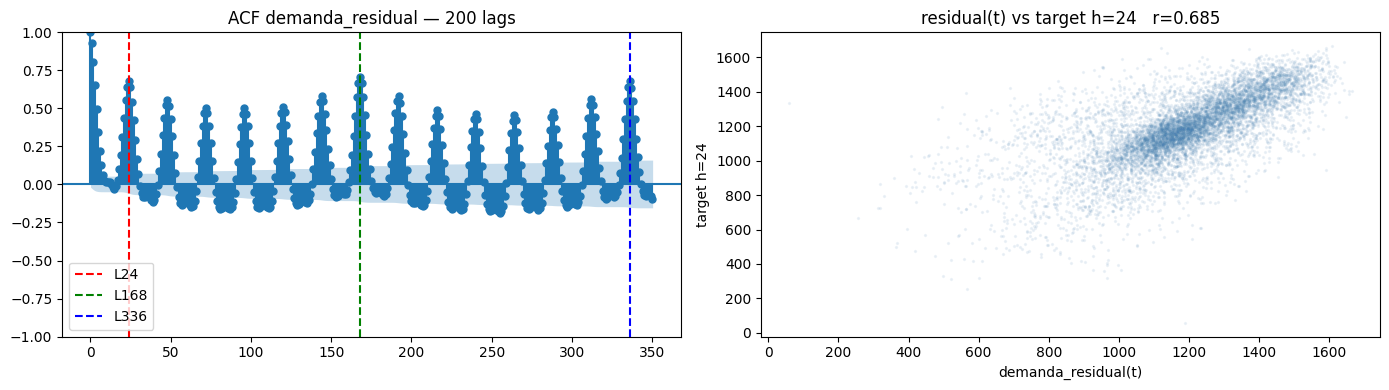

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats.stats import pearsonr
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['demanda_residual'], lags=350, ax=axes[0], alpha=0.05)
# Autocorrelation Function up to lag 200. Blue shading = 95 % confidence band.
# Bars outside the band are statistically significant autocorrelations.

for lag, color, label in [(24, 'red', 'L24'), (168, 'green', 'L168'), (336, 'blue', 'L336')]:
    axes[0].axvline(x=lag, color=color, linestyle='--', linewidth=1.5, label=label)
# Vertical lines highlight the lag values used as features.

axes[0].set_title('ACF demanda_residual — 200 lags')
axes[0].legend()

axes[1].scatter(df['demanda_residual'].values, df['demanda_residual_h24'].values,
                alpha=0.08, s=2, color='steelblue')
# Scatter: current residual demand (x) vs. target 24 h ahead (y).
# Low alpha (0.08) avoids overplotting the ~7 000 training points.

corr_r = df[['demanda_residual', 'demanda_residual_h24']].corr().iloc[0, 1]
axes[1].set_title(f'residual(t) vs target h=24   r={corr_r:.3f}')
axes[1].set_xlabel('demanda_residual(t)')
axes[1].set_ylabel('target h=24')

plt.tight_layout()
plt.show()

#### correlation matrix

If some time series are non-stationary, the Pearson correlation matrix can be misleading
(spurious correlations). We use the KPSS test to identify non-stationary columns.
A KPSS p-value ≤ 1 % means the series is NOT stationary (null hypothesis = stationarity is rejected).

In [17]:
from statsmodels.tsa.stattools import kpss

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    stationarity = pd.DataFrame(
        index=df.columns,
        data=[kpss(df[c])[1] for c in df.columns],
        columns=['KPSS p-value']
    )
# Run KPSS stationarity test for every column.
# If p-value > 0.10 (shown as 0.10) → stationary. We do NOT reject H0.
# If p-value = 0.01 (the minimum reported) → NOT stationary.
stationarity

,KPSS p-value
irradiance_direct,0.010000
irradiance_diffuse,0.010000
temperature,0.010000
solar_mw,0.010000
wind_speed,0.010000
eolica_mw,0.010000
hidro_mw,0.010000
irradiance_direct_h24,0.010000
irradiance_diffuse_h24,0.010000
temperature_h24,0.010000


In [ ]:
r = df[cols_order].corr()
# Compute the Pearson correlation matrix for all 31 columns.

print('Correlations with target (demanda_residual_h24):')
print(r['demanda_residual_h24'].drop('demanda_residual_h24').sort_values(ascending=False).round(3))
# Print the correlation of each feature with the target, sorted highest-to-lowest.
# Key expected findings (from the actual run):
#   demanda_residual (current):   r ≈ 0.69   (strongest single predictor)
#   residual_L144:                r ≈ 0.78 (training-only; strongest lag, target-relative)
#   residual_L312:                r ≈ 0.76 (training-only, target-relative)
#   irradiance_direct_h24:        negative   (high solar → low residual demand)

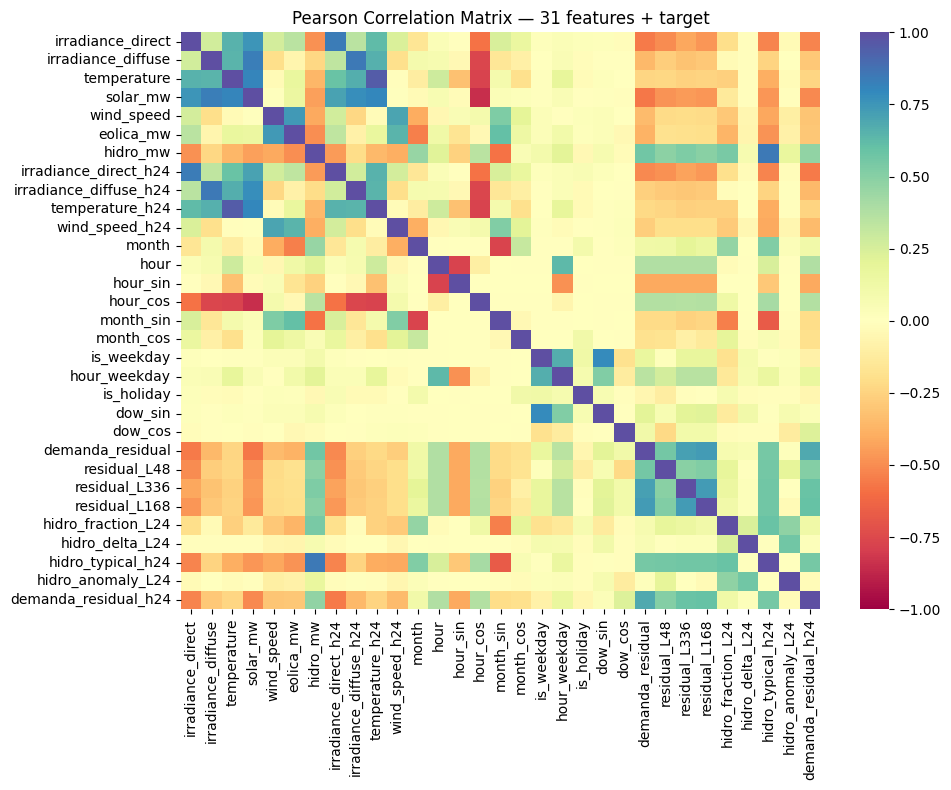

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(r, vmin=-1, vmax=1, annot=False, cmap='Spectral')
plt.title('Pearson Correlation Matrix — 31 features + target')
plt.tight_layout()
plt.show()
# Dark red = strong positive correlation;

## Data structures

`predictions` (dict of lists, training-set predictions per iteration), `forecasts` (dict of
DataFrames, test-set forecasts by datetime), `errors`/`training_errors` (MAPE per model), plus
WAPE/sMAPE/R² equivalents. Two models: `deep_network`, `xgboost`.


In [ ]:
from sklearn.metrics import (mean_absolute_percentage_error, mean_absolute_error,
                              mean_squared_error, r2_score)

def compute_metrics(actual, predicted):
    """
    Compute four error metrics: MAPE, WAPE, sMAPE, R².

    MAPE : standard, but sensitive when residual demand approaches zero.
    WAPE : uses the sum of actuals as denominator — robust near zero.
    sMAPE: symmetric, bounded 0–200 %, avoids MAPE asymmetry.
    R²   : fraction of variance explained; 1.0 = perfect forecast.

    WAPE is consistently ~1 pp lower than MAPE here because during high-solar midday hours
    the residual demand shrinks toward zero, causing MAPE to spike in individual rows.
    The aggregate WAPE denominator dilutes those hours.
    """
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)

    mape  = mean_absolute_percentage_error(actual, predicted)
    # sklearn's MAPE: mean(|actual - predicted| / |actual|).

    wape  = np.sum(np.abs(actual - predicted)) / (np.sum(np.abs(actual)) + 1e-8)
    # Weighted APE: total absolute error / total absolute actual.
    # The 1e-8 guard prevents division by zero on an all-zero actual (edge case).

    smape = np.mean(2 * np.abs(actual - predicted) /
                    (np.abs(actual) + np.abs(predicted) + 1e-8))
    # Symmetric MAPE: 2|e| / (|a| + |p|), averaged across rows.

    r2    = r2_score(actual, predicted)
    # Coefficient of determination: 1 - SS_res / SS_tot.

    return (mape, wape, smape, r2)

In [ ]:
predictions = {
    'deep_network': [],
    'xgboost':      [],
}
# Dictionary of lists.
# Each key is a model name. Each list grows by one entry per rolling iteration:
# entry i is a DataFrame of training-set predictions for the model fitted up to T_day_i.

target_h24   = 'demanda_residual_h24'
# The column name of our prediction target.

features_h24 = [c for c in cols_order if c != target_h24]
# List of all feature column names — every column except the target.
# Should be exactly 30 features.

forecasts = {
    k: pd.DataFrame(data=np.nan, columns=[target_h24], index=target_time)
    for k in predictions
}
# Each DataFrame has one column (target_h24) and one row per hour in the full dataset, indexed
# by target_time — the calendar hour actually being predicted, not the hour the forecast was
# issued from. Rows in the training window stay NaN; the rolling loop fills in the test window.

_cols = list(predictions.keys())
# ['deep_network', 'xgboost'] — used to construct the error DataFrames below.

errors          = pd.DataFrame(index=[target_h24], columns=_cols)
training_errors = pd.DataFrame(index=[target_h24], columns=_cols)
# MAPE DataFrames: rows = targets (only one: demanda_residual_h24), columns = models.

errors_wape    = pd.DataFrame(index=[target_h24], columns=_cols)
errors_smape   = pd.DataFrame(index=[target_h24], columns=_cols)
errors_r2      = pd.DataFrame(index=[target_h24], columns=_cols)
training_wape  = pd.DataFrame(index=[target_h24], columns=_cols)
training_smape = pd.DataFrame(index=[target_h24], columns=_cols)
training_r2    = pd.DataFrame(index=[target_h24], columns=_cols)

## Feature Extraction via Lagged Approach


this is done by the function `get_targets_features`, which returns `Y_train`, `X_train`, `X_test`
based on the **lagged values approach** (the parameter `use_polynomials = False`).

all lag features (`residual_L48`, `residual_L144`, `residual_L312`) and NWP horizon
features (`irradiance_direct_h24`) have already been pre-computed as columns of `df` in Section 1.
The function's job here is simply to **slice** the DataFrame at cutoff `T` to produce training and test splits.

Below we import the `StandardScaler` which is required when `scale=True` (for the DNN).
For XGBoost we use `scale=False` because tree models are scale-invariant.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Applied to X and Y for the DNN only. XGBoost is scale-invariant, so scale=False there.

In [ ]:
def rebuild_hidro_profile_features(df_in, T):
    """
    Recompute the seasonal-diurnal hydro features from TRAINING ROWS ONLY (rows < T).

    Why this exists — leakage prevention:
    `hidro_typical_h24` and `hidro_anomaly_L24` both depend on a (month, hour) mean of
    `hidro_mw`. If that mean is taken once over the full dataset it lets an early rolling
    window "see" hydro levels from months that come after its own cutoff. Here the profile
    is fitted on rows [:T] only and mapped onto every row by calendar key (month, hour) —
    the key itself is not leakage. (month, hour) combinations not yet observed in training
    fall back to the training-window mean of `hidro_mw`.

    Returns a copy of df_in with the two hydro-profile columns overwritten for cutoff T.
    """
    train_profile = df_in.iloc[:T].groupby(['month', 'hour'])['hidro_mw'].mean()
    train_mean    = df_in['hidro_mw'].iloc[:T].mean()
    keys          = zip(df_in['month'].to_numpy(), df_in['hour'].to_numpy())
    base          = pd.Series([train_profile.get(k, train_mean) for k in keys],
                              index=df_in.index, dtype=float)

    out = df_in.copy()
    # Expected hydro at the forecast horizon (h+24); fillna(base) covers the final rows
    # where shift(-HORIZON) has no successor.
    out['hidro_typical_h24'] = base.shift(-HORIZON).fillna(base)
    # Yesterday's deviation of actual hydro from its (training-only) seasonal baseline.
    out['hidro_anomaly_L24'] = (out['hidro_mw'] - base).shift(LAG_1).fillna(0.0)
    return out


def rebuild_calibration_features(df_in, T):
    """
    Re-fit the ninja->real solar calibration from TRAINING ROWS ONLY (rows < T) and apply it to
    the four irradiance features, using ONLY ninja inputs - never target-hour real solar.

    Why this exists - leakage prevention: the factor is a per-hour-of-day mean of
    (real_solar / ninja_solar) fitted on rows < T only (daytime rows, ninja_solar > 0) and applied
    by calendar hour. Because the horizon is +24 h (a whole day), the target's clock-hour equals
    the current row's clock-hour, so the SAME hourly factor calibrates both the current irradiance
    and its _h24 shift. Applying it uses only the raw ninja columns - no real solar from rows >= T.
    """
    train = df_in.iloc[:T]
    day   = train['solar_ninja'] > 0
    ratio = train.loc[day, 'solar_mw'] / train.loc[day, 'solar_ninja']   # solar_mw is REAL here
    k_by_hour = ratio.groupby(train.loc[day, 'hour']).mean()
    k_global  = float(ratio.mean()) if len(ratio) else 1.0
    k = df_in['hour'].map(k_by_hour).fillna(k_global).to_numpy()

    out = df_in.copy()
    out['irradiance_direct']      = (out['irr_direct_ninja'].to_numpy()      * k)
    out['irradiance_diffuse']     = (out['irr_diffuse_ninja'].to_numpy()     * k)
    out['irradiance_direct_h24']  = (out['irr_direct_ninja_h24'].to_numpy()  * k)
    out['irradiance_diffuse_h24'] = (out['irr_diffuse_ninja_h24'].to_numpy() * k)
    return out


def get_targets_features(df_in, T, scale=False):
    """
    Feature extraction — Lagged Approach.

    Parameters
    ----------
    df_in  : DataFrame — the full dataset with all 30 features and the target column.
    T      : int       — training cutoff (number of rows used for training).
    scale  : bool      — if True, apply StandardScaler to X and Y (for DNN);
                         if False, return raw arrays (for XGBoost).

    Returns
    -------
    scale=False → (Y_train, X_train, X_test)
    scale=True  → (Y_train, X_train, X_test, sx, sy)   # sx, sy = fitted feature/target scalers

    The test window covers the next HORIZON=24 rows starting at row T. The seasonal hydro
    features are rebuilt from training-only data (see rebuild_hidro_profile_features) so no
    window is fed information past its own cutoff.
    """
    df_in = rebuild_calibration_features(df_in, T)
    df_in = rebuild_hidro_profile_features(df_in, T)

    Y_train = df_in[[target_h24]].iloc[:T].copy()
    X_train = df_in[features_h24].iloc[:T].copy()
    X_test  = df_in[features_h24].iloc[T:T + HORIZON].copy()

    if scale:
        # Fit scalers on training data only — never on test data (would leak).
        sx = StandardScaler().fit(X_train)
        sy = StandardScaler().fit(Y_train)
        X_train = pd.DataFrame(sx.transform(X_train), columns=X_train.columns)
        X_test  = pd.DataFrame(sx.transform(X_test),  columns=X_test.columns)
        Y_train = pd.DataFrame(sy.transform(Y_train), columns=Y_train.columns)
        return Y_train, X_train, X_test, sx, sy

    return Y_train, X_train, X_test

Below we verify the function by calling it once at the fixed training cutoff T = 7000.
We check that the shapes are correct and that the feature count equals exactly 30.

In [24]:
T_test = 7000
Y_v, X_v, Xt_v = get_targets_features(df_in=df, T=T_test)

print(f'X_train: {X_v.shape}   X_test: {Xt_v.shape}   (should be (7000, 30) and (24, 30))')
print(f'Y_train: {Y_v.shape}   (should be (7000, 1))')

assert X_v.shape[1] == 30, f'Feature count error: {X_v.shape[1]}'
# Hard assertion: the number of features must be exactly 30 as documented in the context.

print(f'\n Shapes correct')
print(f'\nFeature list ({len(features_h24)} features):')
print(features_h24)
# Print the feature list so it is documented in the notebook output.

X_train: (7000, 30)   X_test: (24, 30)   (should be (7000, 30) and (24, 30))
Y_train: (7000, 1)   (should be (7000, 1))

 Shapes correct

Feature list (30 features):
['irradiance_direct', 'irradiance_diffuse', 'temperature', 'solar_mw', 'wind_speed', 'eolica_mw', 'hidro_mw', 'irradiance_direct_h24', 'irradiance_diffuse_h24', 'temperature_h24', 'wind_speed_h24', 'month', 'hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekday', 'hour_weekday', 'is_holiday', 'dow_sin', 'dow_cos', 'demanda_residual', 'residual_L48', 'residual_L336', 'residual_L168', 'hidro_fraction_L24', 'hidro_delta_L24', 'hidro_typical_h24', 'hidro_anomaly_L24']


#Deep Neural Network (DNN) — Rolling h=24


> `Dense(256, relu) → Dense(256, relu) → Dense(128, relu) → Dense(1)`

- Trained with **Adam optimiser** (learning rate 0.001) and **MSE loss**.
- **EarlyStopping** with patience=5 on validation loss; `restore_best_weights=True`.
- Validation split = 10 % (last 10 % of the training window, preserving temporal order).
- Both X and Y are scaled with StandardScaler (for neural networks).
- Seed 42 is fixed at each iteration so results are reproducible.

Adding the NWP horizon (`*_h24`) weather features noticeably improves DNN accuracy over
using calendar and lag features alone.

### 5.1_ Using Rolling Predictions to train the model

The rolling loop below implements **walk-forward (expanding window) validation** — the standard
evaluation protocol for time-series forecasting

For each iteration:
1. The training window expands by one day (`T_day = T + day_idx × HORIZON`).
2. The model is re-fitted on all data up to `T_day`.
3. The model forecasts the next 24 hours (one full day).
4. The forecast is stored in `forecasts['deep_network']` and the training predictions in `predictions['deep_network']`.
5. The model object and all intermediate DataFrames are saved in `globals()` under keys like
   `model_dnn7000`, `X_train_dnn7000`

In [ ]:
import os, random, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm

# tqdm wraps the for-loop and displays a progress bar
# EarlyStopping stops training when val_loss has not improved for 'patience' epochs.

def set_random_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Fix the Python hash seed for determinism across runs.
    tf.random.set_seed(seed)
    # Fix TensorFlow's random seed (affects weight initialisation).
    np.random.seed(seed)
    # Fix NumPy's random seed (affects dropout, shuffling, etc.).
    random.seed(seed)
    # Fix Python's built-in random seed.
# This function ensures that every DNN model in the rolling loop starts with
# the same weight initialisation, making results reproducible.

T               = 7000
# Training cutoff: first T=7000 hours are used for initial training.
# Approximately January 1 – late October 2025 (given ~8,400 valid rows after burn-in).

period_selected = len(df) - T
# Number of hours in the test period.

n_test_days  = period_selected // HORIZON
# Number of complete 24-hour days in the test period.
# Each day = one rolling iteration.

n_test_hours = n_test_days * HORIZON
# Total test hours (rounded down to complete days).

print(f'Train:         {T:,} hours ({T/24:.0f} days)')
print(f'Test:          {period_selected:,} hours ({period_selected/24:.0f} days)')
print(f'Rolling days:  {n_test_days} iterations ({n_test_hours:,} hours in test)')
print(f'Test origin range (forecasts issued):  {origin_time.iloc[T]} → {origin_time.iloc[T + n_test_hours - 1]}')
print(f'Test target range (days being forecast): {target_time.iloc[T]} → {target_time.iloc[T + n_test_hours - 1]}')

# ── Naive benchmark ────────────────────────────────────────────────────────────────
naive_preds  = df['demanda_residual'].iloc[T:T + n_test_hours].values
naive_actual = df[target_h24].iloc[T:T + n_test_hours].values
# Naive model = persistence: predict tomorrow's residual demand = today's residual demand.
# This is the minimum acceptable benchmark: every model must beat it.

naive_mape, naive_wape, naive_smape, naive_r2 = compute_metrics(naive_actual, naive_preds)
print(f'\nNaive: MAPE={naive_mape:.2%}  WAPE={naive_wape:.4f}  sMAPE={naive_smape:.2%}  R²={naive_r2:.4f}')

# Weekly-naive benchmark: predict the SAME clock-hour, exactly one week before
# the TARGET hour. residual_L144 already IS this value - it's shift(144) of demanda_residual,
# and 144h before origin_time equals exactly 168h (1 week) before target_time (= origin_time +
# 24h). No new computation needed, no leakage risk (same backward-only shift as the persistence
# naive above).
weekly_naive_preds = df['residual_L144'].iloc[T:T + n_test_hours].values
weekly_naive_mape, weekly_naive_wape, weekly_naive_smape, weekly_naive_r2 =     compute_metrics(naive_actual, weekly_naive_preds)
print(f'Weekly-naive: MAPE={weekly_naive_mape:.2%}  WAPE={weekly_naive_wape:.4f}  '
      f'sMAPE={weekly_naive_smape:.2%}  R²={weekly_naive_r2:.4f}')

In [ ]:
for day_idx in tqdm(range(n_test_days), desc='DNN rolling h=24'):

    set_random_seeds(42)
    # Reset seeds at the start of each iteration so every DNN model is trained with
    # the same weight initialisation strategy. Reproducibility requires this.

    T_day = T + day_idx * HORIZON
    # The training cutoff for this iteration: T + day 0 → T_day = T, T + day 1 → T+24, etc.
    # The training window expands by 24 hours with each iteration (expanding window).

    Y_train, X_train, X_test, scaler_x, scaler_y =         get_targets_features(df_in=df, T=T_day, scale=True)
    # Extract scaled training and test arrays.
    # scale=True: X_train, X_test, Y_train are all standardised (mean=0, std=1).
    # scaler_x and scaler_y are the fitted scalers — needed for inverse_transform below.

    model = Sequential([
        Dense(256, activation='relu'),
        # First hidden layer: 256 neurons, ReLU activation.
        # ReLU (Rectified Linear Unit) = max(0, x). Avoids the vanishing gradient problem.
        Dense(256, activation='relu'),
        # Second hidden layer: 256 neurons, ReLU. Two layers of 256 give the DNN enough
        # capacity to capture the nonlinear interactions between irradiance, hydro, and demand.
        Dense(128, activation='relu'),
        # Third hidden layer: 128 neurons. Narrows before the output.
        Dense(1)
        # Output layer: 1 neuron (single forecast — demanda_residual_h24 in MW).
        # No activation = linear output, appropriate for regression.
    ])
    model.compile(optimizer=Adam(0.001), loss='mean_squared_error')
    # Adam with lr=0.001: the standard adaptive optimiser. MSE loss for regression.

    model.fit(
        X_train, Y_train,
        epochs=100,          # maximum 100 training epochs
        batch_size=256,      # 256 samples per gradient update (fast for ~7000 rows)
        validation_split=0.1,# last 10 % of training set used for validation
        callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                  restore_best_weights=True)],
        # Stop early if validation loss does not improve for 5 epochs.
        # restore_best_weights=True reloads the weights from the best epoch.
        verbose=0            # suppress per-epoch output (progress bar from tqdm is enough)
    )

    df_Y_pred1 = pd.DataFrame(
        scaler_y.inverse_transform(model.predict(X_train, verbose=0)),
        columns=[target_h24],
        index=target_time[:T_day]
    )
    # Training-set predictions: inverse-transform from the scaled space back to MW.
    # index = target_time — the hour each prediction is actually FOR, not the training
    # row's own origin hour.

    df_Y_pred2 = pd.DataFrame(
        scaler_y.inverse_transform(model.predict(X_test, verbose=0)),
        columns=[target_h24],
        index=target_time[T_day:T_day + HORIZON]
    )
    # Test-set predictions (24-hour forecast): inverse-transform to MW.
    # index = target_time — the 24 calendar hours actually being forecast.

    forecasts['deep_network'].iloc[T_day:T_day + HORIZON] =         df_Y_pred2[target_h24].values.reshape(-1, 1)
    # Store the 24-hour forecast in the forecasts DataFrame at the correct rows.
    # reshape(-1, 1) ensures the array is 2-D for DataFrame assignment.

    predictions['deep_network'].append(df_Y_pred1)
    # Append this iteration's training predictions to the list.
    # The last element predictions['deep_network'][-1] = training predictions for the
    # largest training window (used for training MAPE calculation)

    # store all per-iteration artifacts in globals()
    globals()['model_dnn'        + str(T_day)] = model
    globals()['scaler_x_dnn'     + str(T_day)] = scaler_x
    globals()['scaler_y_dnn'     + str(T_day)] = scaler_y
    globals()['X_train_dnn'      + str(T_day)] = X_train.copy()
    globals()['X_test_dnn'       + str(T_day)] = X_test.copy()
    globals()['df_Y_pred1_dnn'   + str(T_day)] = df_Y_pred1.copy()
    globals()['df_Y_pred2_dnn'   + str(T_day)] = df_Y_pred2.copy()
    globals()['predictions_dnn_' + str(T_day)] = predictions['deep_network'].copy()
    globals()['forecasts_dnn'    + str(T_day)] = forecasts['deep_network'].copy()
    # Each key is the variable name plus T_day (an integer).
    # This allows inspection of any specific rolling-window model after the loop finishes.

### 5.2_ Plotting the test set predictions

Three panels: (1) full test period, (2) first 7 days zoom, (3) absolute error.

In [ ]:
T_last       = T + (n_test_days - 1) * HORIZON
# T_last is the training cutoff of the final rolling iteration.

actual_test  = df[target_h24].iloc[T:T + n_test_hours].values
# Actual residual demand values over the test period.

pred_test    = forecasts['deep_network'][target_h24].iloc[T:T + n_test_hours].values.astype(float)
# DNN forecasts for the test period, retrieved from the forecasts DataFrame.

dates_test   = target_time.iloc[T:T + n_test_hours]
# target_time labels for the test period — x-axis is the day being predicted, not the
# day the forecast was issued from.

test_mape_dnn, test_wape_dnn, test_smape_dnn, test_r2_dnn =     compute_metrics(actual_test, pred_test)
# Compute all four metrics for the test period.

_mae_dnn = mean_absolute_error(actual_test, pred_test)
# Mean Absolute Error in MW — useful for operational interpretation
# (average forecast error expressed in the same unit as demand).

zoom = 7 * HORIZON
# Number of hours to show in the zoom panel: 7 days × 24 hours.

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(dates_test, actual_test, label='Actual', color='steelblue', linewidth=0.8)
axes[0].plot(dates_test, pred_test,   label='DNN Forecast', color='orange', linewidth=0.8)
axes[0].set_title(
    f'DNN h=24 — Test period\n'
    f'MAPE={test_mape_dnn:.2%} | WAPE={test_wape_dnn:.4f} | '
    f'sMAPE={test_smape_dnn:.2%} | R²={test_r2_dnn:.4f} | Naive={naive_mape:.2%}', fontsize=10)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dates_test[:zoom], actual_test[:zoom], color='steelblue', linewidth=1.2, label='Actual')
axes[1].plot(dates_test[:zoom], pred_test[:zoom],   color='orange',    linewidth=1.2, label='DNN h=24')
axes[1].set_title('DNN h=24 — First 7 days (zoom)', fontsize=11)
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].grid(alpha=0.3)

abs_error = np.abs(actual_test - pred_test)
axes[2].fill_between(dates_test, abs_error, alpha=0.5, color='tomato', label='|Error| MW')
axes[2].axhline(_mae_dnn, color='red', linestyle='--', linewidth=1, label=f'MAE={_mae_dnn:.1f} MW')
axes[2].set_title('DNN h=24 — Absolute error', fontsize=11)
axes[2].set_ylabel('MW')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3_ Plotting the training set predictions

We use `predictions['deep_network'][-1]` — the training predictions of the last rolling iteration
(the largest training window).

In [ ]:
actual_train = df[target_h24].iloc[:T_last].values
# Actual residual demand values over the training period.

pred_train   = predictions['deep_network'][-1][target_h24].values
# Training-set predictions from the last rolling iteration (largest window).

dates_train  = target_time.iloc[:T_last]
# target_time labels for the training period.

train_mape_dnn, train_wape_dnn, train_smape_dnn, train_r2_dnn =     compute_metrics(actual_train, pred_train)
# Training-set metrics — used in the overfitting analysis below.

zoom_tr = 7 * HORIZON
# First 7 days for the training zoom panel.

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(dates_train, actual_train, label='Actual', color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].plot(dates_train, pred_train,   label='DNN Training', color='darkorange', linewidth=0.6, alpha=0.8)
axes[0].set_title(
    f'DNN h=24 — Training (T={T_last})\n'
    f'MAPE={train_mape_dnn:.2%} | WAPE={train_wape_dnn:.4f} | R²={train_r2_dnn:.4f}', fontsize=11)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dates_train[:zoom_tr], actual_train[:zoom_tr], color='steelblue', linewidth=1.2, label='Actual')
axes[1].plot(dates_train[:zoom_tr], pred_train[:zoom_tr],   color='darkorange', linewidth=1.2, label='DNN Training (zoom)')
axes[1].set_title('DNN h=24 — Training first 7 days (zoom)', fontsize=11)
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4_ Training set MAPE
### 5.5_ Test set MAPE
### 5.6_ Overfitting analysis
### 5.7_ Naive model benchmark
### 5.8_ Model selection

All four metrics (MAPE, WAPE, sMAPE, R²) for both training and test are stored into the
error DataFrames. Then we check overfitting (test MAPE − train MAPE)
and run the model selection criteria: beat naive AND overfit < 10 pp.

In [ ]:
# ── Store all metrics in the error DataFrames
training_errors.loc[target_h24, 'deep_network'] = train_mape_dnn
training_wape.loc[target_h24,   'deep_network'] = train_wape_dnn
training_smape.loc[target_h24,  'deep_network'] = train_smape_dnn
training_r2.loc[target_h24,     'deep_network'] = train_r2_dnn
# Training-set metrics: fills in the 'deep_network' column of each error DataFrame.

errors.loc[target_h24,       'deep_network'] = test_mape_dnn
errors_wape.loc[target_h24,  'deep_network'] = test_wape_dnn
errors_smape.loc[target_h24, 'deep_network'] = test_smape_dnn
errors_r2.loc[target_h24,    'deep_network'] = test_r2_dnn
# Test-set metrics: fills in the 'deep_network' column.

does_it_overfit_dnn = float(test_mape_dnn - train_mape_dnn)
# Overfitting gap = test MAPE − train MAPE.
# A positive value means the model is generalising imperfectly.
# Threshold is 0.10 (10 pp). DNN target: < 1 pp.

improvement_dnn = (naive_mape - test_mape_dnn) / naive_mape * 100
# Percentage improvement over the naive benchmark.

print(f'DNN Train : MAPE={train_mape_dnn:.2%}  WAPE={train_wape_dnn:.4f}  R²={train_r2_dnn:.4f}')
print(f'DNN Test  : MAPE={test_mape_dnn:.2%}  WAPE={test_wape_dnn:.4f}  sMAPE={test_smape_dnn:.2%}  R²={test_r2_dnn:.4f}')
print(f'DNN Overfit: {does_it_overfit_dnn:.2%}  |  Improvement over naive: {improvement_dnn:.1f} %')
print()

#5.7 Naive model benchmark
print(f'Naive benchmark: MAPE={naive_mape:.2%}  WAPE={naive_wape:.4f}  R²={naive_r2:.4f}')
print()

#5.8 Model selection
print('====== DNN h=24 — MODEL SELECTION ')
if naive_mape <= test_mape_dnn:
    print('The DNN does NOT beat the naive model. Not recommended for forecasts.')
elif does_it_overfit_dnn >= 0.1:
    print(f'The DNN overfits ({does_it_overfit_dnn:.2%} gap). Not recommended for forecasts.')
else:
    print(
        f'*** The DNN is selected for further evaluation. ***\n'
        f'    MAPE={test_mape_dnn:.2%} | R²={test_r2_dnn:.4f} | '
        f'Improvement over naive: {improvement_dnn:.1f} %'
    )
# This check is a minimum bar, not a readiness verdict: beating naive persistence and staying
# under a 10pp overfit gap only means the model clears the first two filters. It does NOT by
# itself mean the model is ready for operational forecasting.

#### XGBoost — Rolling h=24

Tree models are scale-invariant, so no StandardScaler is applied. The validation set is the
last 10 % of the training window, preserving temporal order.


### 6.1_ Using Rolling Predictions to train the model

In [ ]:
from xgboost import XGBRegressor
# XGBRegressor: the scikit-learn compatible XGBoost regression interface.

# XGBoost hyperparameter sweep
# Searches a small grid using ONLY the first rolling window's (T, not T_last) internal
# validation split — rows entirely before the test period starts. T_last's own validation
# slice is avoided because its training rows extend into dates later graded in the results
# table, which would let hyperparameter choice be informed by outcomes it's tested on — a
# soft look-ahead leak into model selection. The winning config is then fixed for every
# iteration of the rolling loop below.

_Y_sweep, _X_sweep, _ = get_targets_features(df_in=df, T=T, scale=False)
_val_size_sweep = max(24, round(len(_X_sweep) * 0.10))
_X_val_sweep = _X_sweep.iloc[-_val_size_sweep:]
_y_val_sweep = _Y_sweep.values.ravel()[-_val_size_sweep:]
_X_tr_sweep  = _X_sweep.iloc[:-_val_size_sweep]
_y_tr_sweep  = _Y_sweep.values.ravel()[:-_val_size_sweep]

XGB_PARAM_GRID = [
    # (max_depth, min_child_weight, reg_alpha, reg_lambda, subsample, colsample_bytree)
    (5, 1,  0.1, 1.0, 0.8, 0.8),   # original config — the baseline this sweep must beat
    (4, 1,  0.1, 1.0, 0.8, 0.8),
    (4, 5,  0.3, 2.0, 0.8, 0.8),
    (4, 5,  0.3, 2.0, 0.7, 0.7),
    (3, 5,  0.3, 2.0, 0.7, 0.7),
    (4, 10, 0.5, 3.0, 0.7, 0.7),
]

_sweep_rows = []
for _md, _mcw, _ra, _rl, _ss, _cs in XGB_PARAM_GRID:
    _m = XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=_md, min_child_weight=_mcw,
        subsample=_ss, colsample_bytree=_cs, reg_alpha=_ra, reg_lambda=_rl,
        early_stopping_rounds=20, random_state=42, verbosity=0, n_jobs=-1,
    )
    _m.fit(_X_tr_sweep, _y_tr_sweep, eval_set=[(_X_val_sweep, _y_val_sweep)], verbose=False)
    _val_mape   = mean_absolute_percentage_error(_y_val_sweep, _m.predict(_X_val_sweep)) * 100
    _train_mape = mean_absolute_percentage_error(_y_tr_sweep, _m.predict(_X_tr_sweep)) * 100
    _sweep_rows.append({
        'max_depth': _md, 'min_child_weight': _mcw, 'reg_alpha': _ra, 'reg_lambda': _rl,
        'subsample': _ss, 'colsample_bytree': _cs,
        'val_mape': _val_mape, 'train_mape': _train_mape, 'gap': _val_mape - _train_mape,
    })

_sweep_df = pd.DataFrame(_sweep_rows).sort_values('val_mape').reset_index(drop=True)
print('XGBoost hyperparameter sweep (validation-only, T window — before the test period, untouched):')
print(_sweep_df.round(3).to_string())

_best_row = _sweep_df.iloc[0]
XGB_PARAMS = dict(
    max_depth=int(_best_row['max_depth']), min_child_weight=int(_best_row['min_child_weight']),
    reg_alpha=float(_best_row['reg_alpha']), reg_lambda=float(_best_row['reg_lambda']),
    subsample=float(_best_row['subsample']), colsample_bytree=float(_best_row['colsample_bytree']),
)
print(f'\nSelected XGBoost config (lowest validation MAPE): {XGB_PARAMS}')

In [ ]:
for day_idx in tqdm(range(n_test_days), desc='XGBoost rolling h=24'):

    T_day = T + day_idx * HORIZON
    # Training cutoff for this iteration (same expanding-window logic as DNN).

    Y_train_xgb, X_train_xgb, X_test_xgb =         get_targets_features(df_in=df, T=T_day, scale=False)
    # scale=False: no StandardScaler for XGBoost — tree models are scale-invariant.
    # Returns raw DataFrames (not numpy arrays), which XGBoost handles natively.

    # Temporal validation set: last 10 % of training window
    val_size  = max(24, round(len(X_train_xgb) * 0.10))
    # At least 24 hours for the validation set. round() then max() ensures
    # we always have a meaningful validation set even at the start of the rolling loop.

    X_val_xgb = X_train_xgb.iloc[-val_size:]
    y_val_xgb = Y_train_xgb.values.ravel()[-val_size:]
    # Validation set: the LAST val_size rows of the training window (most recent data).
    # Using the last 10 % (not a random split) preserves temporal order — the validation
    # set is more similar in distribution to the test set (same season / time of year).

    X_tr_xgb = X_train_xgb.iloc[:-val_size]
    y_tr_xgb = Y_train_xgb.values.ravel()[:-val_size]
    # The actual training subset: all rows up to the start of the validation window.
    # .ravel() converts the (N, 1) DataFrame to a 1-D array as required by XGBoost.

    model_xgb = XGBRegressor(
        n_estimators=500,       # maximum number of boosting rounds (trees)
        learning_rate=0.03,     # shrinkage per round — smaller = more robust
        **XGB_PARAMS,           # max_depth, min_child_weight, reg_alpha, reg_lambda,
                                 # subsample, colsample_bytree — chosen by the P5 sweep above
        early_stopping_rounds=20,  # CONSTRUCTOR (XGBoost ≥ 2.0 requirement)
        # Stop if validation metric has not improved for 20 consecutive rounds.
        random_state=42,        # random seed for reproducibility
        verbosity=0,            # suppress all XGBoost console output
        n_jobs=-1               # use all available CPU cores
    )
    model_xgb.fit(
        X_tr_xgb, y_tr_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        # eval_set provides the validation data for early stopping.
        verbose=False
        # verbose=False suppresses per-round eval output (separate from verbosity=0 above).
    )

    df_Y_pred1_xgb = pd.DataFrame(
        model_xgb.predict(X_train_xgb),
        columns=[target_h24],
        index=target_time[:T_day]
    )
    # Training predictions in MW (no inverse_transform needed — XGBoost is unscaled).

    df_Y_pred2_xgb = pd.DataFrame(
        model_xgb.predict(X_test_xgb),
        columns=[target_h24],
        index=target_time[T_day:T_day + HORIZON]
    )
    # 24-hour test forecast in MW.

    forecasts['xgboost'].iloc[T_day:T_day + HORIZON] =         df_Y_pred2_xgb[target_h24].values.reshape(-1, 1)
    # Store in the forecasts DataFrame (same pattern as DNN section 5.1).

    predictions['xgboost'].append(df_Y_pred1_xgb)
    # Append training predictions to the list.


    globals()['model_xgb'        + str(T_day)] = model_xgb
    globals()['X_train_xgb'      + str(T_day)] = X_train_xgb.copy()
    globals()['X_test_xgb'       + str(T_day)] = X_test_xgb.copy()
    globals()['df_Y_pred1_xgb'   + str(T_day)] = df_Y_pred1_xgb.copy()
    globals()['df_Y_pred2_xgb'   + str(T_day)] = df_Y_pred2_xgb.copy()
    globals()['predictions_xgb_' + str(T_day)] = predictions['xgboost'].copy()
    globals()['forecasts_xgb'    + str(T_day)] = forecasts['xgboost'].copy()

### 6.2_ Plotting the test set predictions

In [ ]:
actual_test_xgb = df[target_h24].iloc[T:T + n_test_hours].values
# Actual residual demand values over the test period (same as for DNN).

pred_test_xgb   = forecasts['xgboost'][target_h24].iloc[T:T + n_test_hours].values.astype(float)
# XGBoost day-ahead forecasts for the test period.

dates_test_xgb  = target_time.iloc[T:T + n_test_hours]
# target_time labels for the test period.

test_mape_xgb, test_wape_xgb, test_smape_xgb, test_r2_xgb =     compute_metrics(actual_test_xgb, pred_test_xgb)
# All four metrics for the test period.

_mae_xgb = mean_absolute_error(actual_test_xgb, pred_test_xgb)
# Mean absolute error in MW.

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(dates_test_xgb, actual_test_xgb, label='Actual',  color='steelblue',  linewidth=0.8)
axes[0].plot(dates_test_xgb, pred_test_xgb,   label='XGBoost', color='darkorange', linewidth=0.8)
axes[0].set_title(
    f'XGBoost h=24 — Test period\n'
    f'MAPE={test_mape_xgb:.2%} | WAPE={test_wape_xgb:.4f} | '
    f'sMAPE={test_smape_xgb:.2%} | R²={test_r2_xgb:.4f} | Naive={naive_mape:.2%}', fontsize=10)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dates_test_xgb[:zoom], actual_test_xgb[:zoom], color='steelblue',  linewidth=1.2, label='Actual')
axes[1].plot(dates_test_xgb[:zoom], pred_test_xgb[:zoom],   color='darkorange', linewidth=1.2, label='XGBoost h=24')
axes[1].set_title('XGBoost h=24 — First 7 days (zoom)', fontsize=11)
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].grid(alpha=0.3)

abs_error_xgb = np.abs(actual_test_xgb - pred_test_xgb)
axes[2].fill_between(dates_test_xgb, abs_error_xgb, alpha=0.5, color='darkorange', label='|Error| MW')
axes[2].axhline(_mae_xgb, color='saddlebrown', linestyle='--', linewidth=1, label=f'MAE={_mae_xgb:.1f} MW')
axes[2].set_title('XGBoost h=24 — Absolute error', fontsize=11)
axes[2].set_ylabel('MW')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3_ Plotting the training set predictions

In [ ]:
actual_train_xgb = df[target_h24].iloc[:T_last].values
# Actual residual demand over the training period.

pred_train_xgb   = predictions['xgboost'][-1][target_h24].values
# Training predictions from the last rolling iteration.

train_mape_xgb, train_wape_xgb, train_smape_xgb, train_r2_xgb =     compute_metrics(actual_train_xgb, pred_train_xgb)
# Training-set metrics.

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(target_time.iloc[:T_last], actual_train_xgb,
             label='Actual', color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].plot(target_time.iloc[:T_last], pred_train_xgb,
             label='XGBoost Training', color='darkorange', linewidth=0.6, alpha=0.8)
axes[0].set_title(
    f'XGBoost h=24 — Training\n'
    f'MAPE={train_mape_xgb:.2%} | WAPE={train_wape_xgb:.4f} | R²={train_r2_xgb:.4f}', fontsize=11)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(target_time.iloc[:zoom_tr], actual_train_xgb[:zoom_tr],
             color='steelblue',  linewidth=1.2, label='Actual')
axes[1].plot(target_time.iloc[:zoom_tr], pred_train_xgb[:zoom_tr],
             color='darkorange', linewidth=1.2, label='XGBoost (zoom)')
axes[1].set_title('XGBoost h=24 — Training first 7 days (zoom)', fontsize=11)
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4_ Feature Importance

XGBoost computes feature importance as the mean **gain** contributed by a feature across all tree splits.
Higher gain = the feature creates larger reductions in the loss function.

Expected top features:
1. `demanda_residual` (0.244) — the current residual demand is the single best predictor.
2. `hour` (0.175) — strong diurnal cycle.
3. `irradiance_direct_h24` (0.080) — NWP horizon, confirms the h24 meteorological hypothesis.
4. `hour_sin` (0.059)
5. `residual_L312` (0.058)

In [ ]:
model_xgb_last   = globals()['model_xgb'   + str(T_last)]
# Retrieve the XGBoost model fitted on the largest training window.

X_train_xgb_last = globals()['X_train_xgb' + str(T_last)]
# Retrieve the corresponding feature matrix (needed for column names).

importance_xgb = pd.Series(
    model_xgb_last.feature_importances_,
    index=X_train_xgb_last.columns
).sort_values(ascending=True)
# feature_importances_ returns an array of gain values, one per feature.
# We wrap it in a Series with column names as the index, then sort for a readable bar chart.

plt.figure(figsize=(9, 7))
importance_xgb.plot(kind='barh', color='darkorange')
# Horizontal bar chart: each bar = one feature, length = importance gain.
plt.title(f'XGBoost h=24 — Feature Importance (T={T_last})')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_xgb.sort_values(ascending=False).head(10).round(4).to_dict())
# Print the top 10 features and their importance scores.

print(f'\nBest n_estimators (early stopping): {model_xgb_last.best_iteration}')
# best_iteration: the tree count at which early stopping triggered.
# A value well below 500 means the model converged before the maximum.

### 6.5_ Training set MAPE
### 6.6_ Test set MAPE
### 6.7_ Overfitting analysis
### 6.8_ Model selection

In [ ]:
# Store all metrics in the DataFrames
training_errors.loc[target_h24, 'xgboost'] = train_mape_xgb
training_wape.loc[target_h24,   'xgboost'] = train_wape_xgb
training_smape.loc[target_h24,  'xgboost'] = train_smape_xgb
training_r2.loc[target_h24,     'xgboost'] = train_r2_xgb

errors.loc[target_h24,       'xgboost'] = test_mape_xgb
errors_wape.loc[target_h24,  'xgboost'] = test_wape_xgb
errors_smape.loc[target_h24, 'xgboost'] = test_smape_xgb
errors_r2.loc[target_h24,    'xgboost'] = test_r2_xgb
# Same pattern as DNN — fill in the 'xgboost' column of each error DataFrame.

does_it_overfit_xgb = float(test_mape_xgb - train_mape_xgb)
# Overfitting gap for XGBoost.

improvement_xgb = (naive_mape - test_mape_xgb) / naive_mape * 100
# Percentage improvement over the naive benchmark.

print(f'XGB Train : MAPE={train_mape_xgb:.2%}  WAPE={train_wape_xgb:.4f}  R²={train_r2_xgb:.4f}')
print(f'XGB Test  : MAPE={test_mape_xgb:.2%}  WAPE={test_wape_xgb:.4f}  sMAPE={test_smape_xgb:.2%}  R²={test_r2_xgb:.4f}')
print(f'XGB Overfit: {does_it_overfit_xgb:.2%}  |  Improvement over naive: {improvement_xgb:.1f} %')
print()

#Model selection
print('====== XGBoost h=24 — MODEL SELECTION')
if naive_mape <= test_mape_xgb:
    print('XGBoost does NOT beat the naive model. Not recommended for forecasts.')
elif does_it_overfit_xgb >= 0.1:
    print(f'XGBoost overfits ({does_it_overfit_xgb:.2%} gap). Not recommended for forecasts.')
else:
    print(
        f'*** XGBoost is selected for further evaluation. ***\n'
        f'    MAPE={test_mape_xgb:.2%} | R²={test_r2_xgb:.4f} | '
        f'Improvement over naive: {improvement_xgb:.1f} %'
    )

#Model Comparison

 DNN + XGBoost only**

The comparison table below aggregates all metrics and includes:
- The naive benchmark for context.
- Model selection result (beat naive + no overfit).

In [ ]:
# ── Side-by-side plot: 2 models, first 7 test days
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# One panel per model, side by side for direct visual comparison.

dates_plot  = target_time.iloc[T:T + n_test_hours]  # x-axis = day being predicted
actual_plot = df[target_h24].iloc[T:T + n_test_hours].values

all_preds = {
    'DNN':     forecasts['deep_network'][target_h24].iloc[T:T + n_test_hours].values.astype(float),
    'XGBoost': forecasts['xgboost'][target_h24].iloc[T:T + n_test_hours].values.astype(float),
}

for ax, (name, preds), color in zip(axes, all_preds.items(), ['orange', 'darkorange']):
    m, wv, sv, r2v = compute_metrics(actual_plot, preds)
    ax.plot(dates_plot[:zoom], actual_plot[:zoom],
            color='steelblue', linewidth=1.0, label='Actual', alpha=0.8)
    ax.plot(dates_plot[:zoom], preds[:zoom],
            color=color,       linewidth=1.0, label=name)
    ax.set_title(f'{name}\nMAPE={m:.2%} | WAPE={wv:.4f} | R²={r2v:.4f}', fontsize=10)
    ax.set_ylabel('MW')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    # Each panel shows the first 7 test days (zoom = 168 hours).
    # Showing the full test period (1392 hours) on a 6-inch wide panel would make
    # individual forecast cycles unreadable.

plt.suptitle(
    'DNN vs XGBoost | Lagged Approach | 30 Features | First 7 Test Days',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Linear regression baseline
# Simple OLS, walk-forward rolling like DNN/XGBoost (same leakage-safe feature pipeline), to
# show whether DNN/XGBoost add value over something simpler. Test-set predictions only — no
# tuning, plots, or overfit tracking; a comparison baseline, not a candidate model.

from sklearn.linear_model import LinearRegression

linear_preds = np.full(n_test_hours, np.nan)
for day_idx in tqdm(range(n_test_days), desc='Linear rolling h=24'):
    T_day = T + day_idx * HORIZON
    Y_train_lin, X_train_lin, X_test_lin = get_targets_features(df_in=df, T=T_day, scale=False)
    lin_model = LinearRegression().fit(X_train_lin, Y_train_lin)
    linear_preds[day_idx * HORIZON:(day_idx + 1) * HORIZON] =         lin_model.predict(X_test_lin).reshape(-1)

linear_mape, linear_wape, linear_smape, linear_r2 = compute_metrics(naive_actual, linear_preds)
print(f'Linear regression: MAPE={linear_mape:.2%}  WAPE={linear_wape:.4f}  '
      f'sMAPE={linear_smape:.2%}  R²={linear_r2:.4f}')


## Results summary — relative and absolute error

Percentage metrics (**MAPE**, **WAPE**) give relative accuracy; **MAE** and **RMSE** report the
same test-period errors in **MW** so the operational magnitude is explicit alongside the ratios.

In [ ]:
def rmse_mw(actual, predicted):
    """Root mean squared error in MW."""
    return float(np.sqrt(mean_squared_error(actual, predicted)))

_test_actual = df[target_h24].iloc[T:T + n_test_hours].values.astype(float)
_pred_dnn = forecasts['deep_network'][target_h24].iloc[T:T + n_test_hours].values.astype(float)
_pred_xgb = forecasts['xgboost'][target_h24].iloc[T:T + n_test_hours].values.astype(float)

# Ensemble: unweighted mean of the two models' stored forecasts.
# No retraining involved — the DNN and XGBoost miss on different hours, so
# averaging tends to cancel part of each model's error.
_pred_ens = 0.5 * (_pred_dnn + _pred_xgb)

_summary_rows = {
    'DNN':           _pred_dnn,
    'XGBoost':       _pred_xgb,
    'Ensemble':      _pred_ens,
    'Linear':        linear_preds.astype(float),
    'Naive':         naive_preds.astype(float),
    'Weekly-Naive':  weekly_naive_preds.astype(float),
}

results_summary = pd.DataFrame(
    [
        {
            'MAPE_%':  compute_metrics(_test_actual, _p)[0] * 100,
            'WAPE_%':  compute_metrics(_test_actual, _p)[1] * 100,
            'MAE_MW':  mean_absolute_error(_test_actual, _p),
            'RMSE_MW': rmse_mw(_test_actual, _p),
        }
        for _p in _summary_rows.values()
    ],
    index=list(_summary_rows.keys()),
).round({'MAPE_%': 2, 'WAPE_%': 2, 'MAE_MW': 1, 'RMSE_MW': 1})

print(f'Test-period results (h=24, {n_test_days} rolling days):')
print(results_summary.to_string())

# Persist this run's metrics and forecasts to disk — these files are the ground truth
# for a given run.
results_summary.to_csv('results_summary.csv')

_test_origin_dates = origin_time.iloc[T:T + n_test_hours].reset_index(drop=True)
_test_target_dates = target_time.iloc[T:T + n_test_hours].reset_index(drop=True)
forecasts_out = pd.DataFrame({
    'origin_time': _test_origin_dates,   # when the forecast was issued
    'target_time': _test_target_dates,   # the hour actually being predicted, = origin + 24h
    'actual':   _test_actual,
    'dnn':      _pred_dnn,
    'xgboost':  _pred_xgb,
    'ensemble': _pred_ens,
    'naive':    naive_preds.astype(float),
}).set_index('target_time')
forecasts_out.to_csv('forecasts.csv')
print(f"\nSaved 'results_summary.csv' and 'forecasts.csv' ({len(forecasts_out)} rows) for this run.")

In [ ]:
# Full test period — Actual vs Ensemble

plt.figure(figsize=(16, 5))
plt.plot(_test_target_dates, _test_actual, color='steelblue', linewidth=0.8, label='Actual Residual Demand')
plt.plot(_test_target_dates, _pred_ens, color='crimson', linewidth=0.8, linestyle='--', label='Ensemble Forecast')
plt.title(f'Full Test Period Forecast (Ensemble Model): {len(_test_target_dates)} Hours')
plt.xlabel('Target Date')
plt.ylabel('Residual Demand (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Ensemble MAE by hour of day

_hourly_mae = (
    pd.DataFrame({'hour': _test_target_dates.dt.hour, 'abs_err': np.abs(_test_actual - _pred_ens)})
    .groupby('hour')['abs_err'].mean()
    .reindex(range(24))
)

plt.figure(figsize=(12, 5))
plt.bar(_hourly_mae.index, _hourly_mae.values, color=plt.cm.magma(np.linspace(0.05, 0.95, 24)))
plt.title('Average Forecast Error (MAE) by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Mean Absolute Error (MW)')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
